In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr
import numpy as np

## Cargamos los datos

In [2]:
df = pd.read_parquet(r"C:\Users\gemma\ProjecteData\Equip_15\Data\RRHH_07102025_clean.parquet")


#pd.set_option("display.max_rows", None)
#pd.set_option("display.max_columns", None)
#df
df.dtypes

ID                                  int64
Reason_absence             string[python]
Month_absence              string[python]
Day_week                   string[python]
Seasons                    string[python]
Transportation_expense            float64
Distance_Residence_Work           float64
Service_time                      float64
Age                               float64
Work_load_Average_day             float64
Hit_target                        float64
Disciplinary_failure                int64
Education                  string[python]
Son                                 int64
Social_drinker                      int64
Social_smoker                       int64
Pet                                 int64
Weight                            float64
Height                            float64
Body_mass_index                   float64
Absenteeism_hours                 float64
Reason_absence_numeric              int64
Education_numeric                   int64
Month_absence_order               

In [3]:
df.shape[0]

1056

# Plan de análisis

## Objetivo 1

Pregunta: Influeixen l’antiguitat, la càrrega laboral diària o la distància fins al lloc de treball en el rendiment dels nostres col·laboradors?

Análisis: regersión lineal múltiple hit_target_avg = antiguitat + workload + distance

## Objetivo 2

Pregunta: Podem identificar perfils amb major risc de baix rendiment i fer ajustaments en l’organització per potenciar els resultats?

Análisis: 
 - Opción 1: regresión lineal múltiple hit_target_avg = todas las variables personales. Así determinamos cuáles son las más significativas y construímos un perfil a partir de ahí 
 - Opción 2: mirar si los clusters sociodemográficos previamente construidos presentan diferencias en cuanto a rendimiento. 

# Clustering variables sociodemográficas

In [4]:
## Cluster
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

# Agrupar por ID 
df_orig = df.groupby("ID").first()[[
    "Age", "Distance_Residence_Work", "Transportation_expense",
    "Son", "Education", "Social_drinker", "Social_smoker"
]].copy()

# Columnas numéricas y categóricas
num_cols = ["Age", "Distance_Residence_Work", "Transportation_expense", "Son"]
cat_cols = ["Education", "Social_drinker", "Social_smoker"]

# Preparamos un dataframe para K-Prototypes: escalamos SOLO las numéricas
df_kp = df_orig.copy()
scaler = StandardScaler()
df_kp[num_cols] = scaler.fit_transform(df_kp[num_cols])

# Aseguramos que las categóricas sean strings (requerido por k-prototypes)
for c in cat_cols:
    df_kp[c] = df_kp[c].astype(str)
# índices de columnas categóricas para k-prototypes
cat_idx = [df_kp.columns.get_loc(c) for c in cat_cols]

# Ejecutar K-Prototypes
kproto = KPrototypes(n_clusters=4, random_state=42, init='Cao')
clusters = kproto.fit_predict(df_kp.values, categorical=cat_idx)
df_orig["cluster"] = clusters

# Resumen numérico en unidades originales (medias)
cluster_num_summary = df_orig.groupby("cluster")[num_cols].mean()
print("Resumen numérico (unidades originales):")
print(cluster_num_summary.round(3))

# Resumen categórico: proporciones por cluster (por ejemplo % bebedores/fumadores y distribución de Education)
print("\nProporciones por cluster (categóricas):")
for c in cat_cols:
    prop = df_orig.groupby("cluster")[c].value_counts(normalize=True).unstack(fill_value=0)
    print(f"\n== {c} ==")
    print((prop*100).round(1))   # en porcentaje

# Modo (valor más frecuente) por cluster para las categóricas
mode_cat = df_orig.groupby("cluster")[cat_cols].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
print("\nModo (valor más frecuente) de las categóricas por cluster:")
print(mode_cat)

# Tamaño e IDs por cluster
print("\nTamaño por cluster:")
print(df_orig['cluster'].value_counts().sort_index())
print("\nIDs por cluster:")
for c in sorted(df_orig['cluster'].unique()):
    ids = df_orig[df_orig['cluster'] == c].index.tolist()
    print(f"\nCluster {c} ({len(ids)} empleados):")
    print(ids)


## Centroides y score
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np
# 1) Centroides interpretables
def mode_series(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

centroids_num = df_orig.groupby("cluster")[num_cols].mean()           # medias en unidades originales
centroids_cat = df_orig.groupby("cluster")[cat_cols].agg(mode_series) # moda de categóricas
centroids_readable = pd.concat([centroids_num, centroids_cat], axis=1)

print("\nCentroides interpretables (numérico = media; categórico = moda):")
print(centroids_readable.round(3))

# 2) Silhouette score - Opción A: SOLO numéricas escaladas
# usamos el scaler que ya tienes (entrenado sobre num_cols)
X_num_scaled = scaler.transform(df_orig[num_cols])   # df_orig tiene las num en unidades originales
sil_num = silhouette_score(X_num_scaled, df_orig['cluster'])
print(f"\nSilhouette (solo numéricas escaladas): {sil_num:.4f}")

# 3) Silhouette score - Opción B: numéricas + categóricas (One-Hot)
# Preparamos ColumnTransformer: escala numéricas y one-hot para categóricas
ct = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    remainder="drop"
)

# Nota: usamos df_orig (unidades originales); ColumnTransformer hará el scaling
X_mixed = ct.fit_transform(df_orig[num_cols + cat_cols])
sil_mixed = silhouette_score(X_mixed, df_orig['cluster'])
print(f"Silhouette (numéricas + one-hot categóricas): {sil_mixed:.4f}")

# 4) Tamaño por cluster y muestra de centroides internos de kproto (opcional)
print("\nTamaño por cluster:")
print(df_orig['cluster'].value_counts().sort_index())

# kproto.cluster_centroids_ existe pero tiene formato interno: 
# numéricas (centroides continuos) y categóricas (modas como índices)
try:
    kp_centroids = kproto.cluster_centroids_
    print("\nCentroides internos reportados por kproto (formato interno):")
    print(kp_centroids)
except Exception:
    pass

# 5) Mensajes interpretativos rápidos
print("""
NOTAS:
- Silhouette (A) usa sólo numéricas: rápido, pero ignora info categórica.
- Silhouette (B) usa numéricas + one-hot: más representativo para datos mixtos,
  aunque la dimensionalidad sube y puede afectar el valor.
- Interpretación de Silhouette: >0.5 bueno, 0.2-0.5 moderado, <0.2 débil.
- Los centroides 'readable' muestran la media (num) y la moda (cat) por cluster,
  úsalos para nominar/explicar cada cluster.
""")

# Imprimir cost
print("Cost del clustering:", kproto.cost_)

Resumen numérico (unidades originales):
            Age  Distance_Residence_Work  Transportation_expense    Son
cluster                                                                
0        37.739                   50.884                 188.565  0.058
1        44.698                   21.519                 224.075  1.321
2        31.734                   19.811                 193.846  0.706
3        33.382                   41.059                 304.794  2.691

Proporciones por cluster (categóricas):

== Education ==
Education  Graduate  High school  Master/Doctor  Postgraduate
cluster                                                      
0               5.8         94.2            0.0           0.0
1               9.4         85.8            4.7           0.0
2               5.6         69.9            0.0          24.5
3               0.0        100.0            0.0           0.0

== Social_drinker ==
Social_drinker     0     1
cluster                   
0                2.9  

### Incorporem el cluster sociodemogràfic a la taula

In [5]:
# Crear una taula de mapeig ID -> cluster
df_clusters = df_orig[["cluster"]].reset_index()
df_clusters.rename(columns={"cluster": "cluster_sociodemografic"}, inplace=True)

# Diccionari de mapeig
cluster_map = {
    3: "Adultos, casi sin hijos, transporte medio, muy bebedores",
    2: "Adultos, pocos hijos, distancia media, bebedores, algo fumadores",
    1: "Jovenes, pocos hijos, poco transporte, no beben ni fuman",
    0: "Jovenes adultos, muchos hijos, gasto transporte alto, bebedores"
}

# Aplicar el canvi
df_clusters['cluster_sociodemografic'] = df_clusters['cluster_sociodemografic'].map(cluster_map)

# Fer el join amb el dataframe original
df = df.merge(df_clusters, on="ID", how="left")

# Comprovar
df.head()


,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Weight,Height,Body_mass_index,Absenteeism_hours,Reason_absence_numeric,Education_numeric,Month_absence_order,Day_week_order,Seasons_order,cluster_sociodemografic
0,14,Enfermedades del sistema digestivo,Noviembre,Lunes,Primavera,155.0,12.0,14.0,34.0,284.031,...,95.0,196.0,25.0,120.0,11,1,11.0,2,4,"Adultos, pocos hijos, distancia media, bebedor..."
1,36,Enfermedades del sistema musculoesquelético y ...,Abril,Miercoles,Verano,118.0,13.0,18.0,50.0,239.409,...,98.0,178.0,31.0,120.0,13,1,4.0,4,3,"Jovenes, pocos hijos, poco transporte, no bebe..."
2,9,Enfermedades del sistema nervioso,Julio,Martes,Invierno,228.0,14.0,16.0,58.0,264.604,...,65.0,172.0,22.0,120.0,6,1,7.0,3,1,"Jovenes, pocos hijos, poco transporte, no bebe..."
3,28,Enfermedades del sistema circulatorio,Julio,Martes,Invierno,225.0,26.0,9.0,28.0,230.290,...,69.0,169.0,24.0,112.0,9,1,7.0,3,1,"Adultos, pocos hijos, distancia media, bebedor..."
4,9,Enfermedades de la piel y tejido subcutáneo,Marzo,Martes,Otono,228.0,14.0,16.0,58.0,222.196,...,65.0,172.0,22.0,112.0,12,1,3.0,3,2,"Jovenes, pocos hijos, poco transporte, no bebe..."


# Cálculo de variables

In [6]:
pd.set_option("display.max.columns", None)
# Calculamos la media de hit target de cada trabajador 
df['Hit_target_avg'] = df.groupby('ID')['Hit_target'].transform('mean')

# Calculamos la media de Work_load_Average_day de cada trabajador
df['Work_load_Average_day'] = df.groupby('ID')['Work_load_Average_day'].transform('mean')

# Calcular número d'absències per treballador
df['count_absenteeism'] = (
    (df['Absenteeism_hours'] != 0)  
    .groupby(df['ID'])              
    .transform('sum')               
)

# Calcular quantes absències injustificades té cada treballador
df["unjustified_absence"] = (
    (df["Reason_absence"] == "26")
    .groupby(df["ID"])
    .transform("sum")
)

# Suma total d'hores d'absència per treballador
df["sum_absenteeism_hours"] = df.groupby("ID")["Absenteeism_hours"].transform("sum")

# Determinem si en algun moment han tingut una falta disciplinària
df["Disciplinary_failure"] = df.groupby("ID")["Disciplinary_failure"].transform(lambda x: int(x.max()))

# Ens quedem amb una única observació per treballador
df = df.drop_duplicates(subset=["ID"], keep="last").reset_index(drop=True)

# Eliminem les variables que ja han perdut sentit
df = df.drop(columns=["Reason_absence","Month_absence", "Day_week", "Seasons","Hit_target","Absenteeism_hours","Education_numeric","Month_absence_order","Day_week_order","Seasons_order"])

# Passar les binàries a boolean
cat_vars = ['Social_drinker', 'Social_smoker', 'Disciplinary_failure']
for col in cat_vars:
    df[col] = df[col].astype(bool)

df.head()

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Reason_absence_numeric,cluster_sociodemografic,Hit_target_avg,count_absenteeism,unjustified_absence,sum_absenteeism_hours
0,6,189.0,29.0,13.0,33.0,274.829000,False,High school,2,False,False,2,69.0,167.0,25.0,13,"Adultos, pocos hijos, distancia media, bebedor...",94.875000,8,0,72.0
1,16,118.0,15.0,24.0,46.0,248.642500,False,High school,2,True,True,0,75.0,175.0,25.0,7,"Jovenes, pocos hijos, poco transporte, no bebe...",97.500000,2,0,16.0
2,25,235.0,16.0,8.0,32.0,254.817500,False,Postgraduate,0,False,False,0,75.0,178.0,25.0,23,"Adultos, pocos hijos, distancia media, bebedor...",95.600000,10,0,42.0
3,12,233.0,51.0,1.0,31.0,271.274000,False,Graduate,1,True,False,8,68.0,178.0,21.0,19,"Jovenes adultos, muchos hijos, gasto transport...",96.142857,7,0,34.0
4,27,184.0,42.0,7.0,27.0,299.956333,False,High school,0,False,False,0,58.0,167.0,21.0,23,"Adultos, pocos hijos, distancia media, bebedor...",95.166667,6,0,25.0


# Objetivo 1

Pregunta: Influeixen l’antiguitat, la càrrega laboral diària o la distància fins al lloc de treball en el rendiment dels nostres col·laboradors?

## Correlaciones

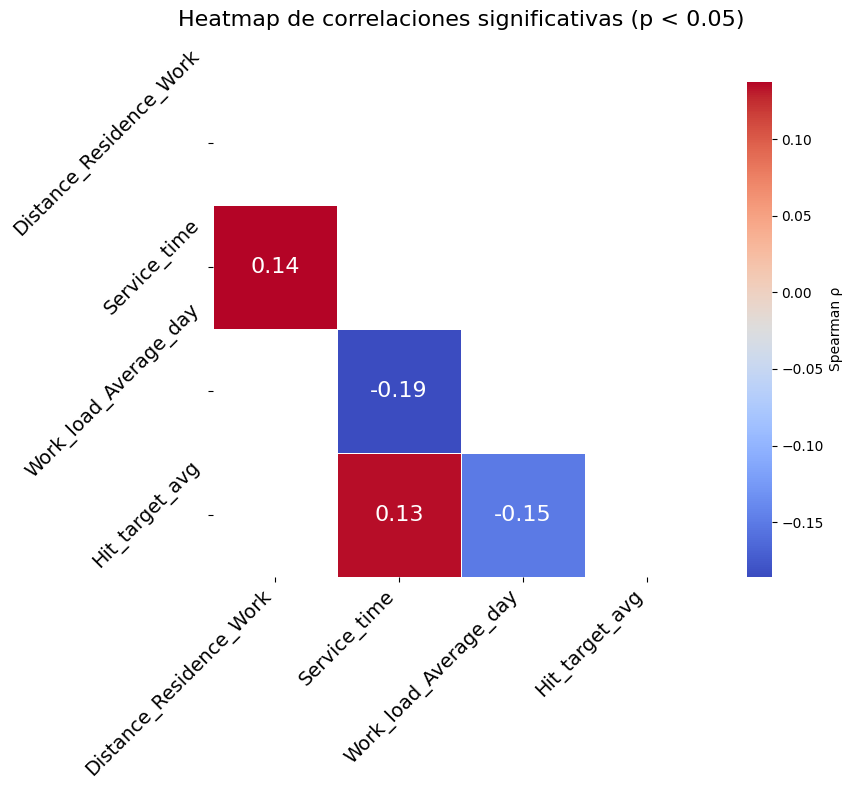

In [25]:
# Variables de interés
vars_interes = [
    "Distance_Residence_Work","Service_time","Work_load_Average_day","Hit_target_avg"
]

# Inicializar matrices de correlación y p-valores
n = len(vars_interes)
corr_matrix = pd.DataFrame(np.zeros((n, n)), index=vars_interes, columns=vars_interes)
pval_matrix = pd.DataFrame(np.zeros((n, n)), index=vars_interes, columns=vars_interes)

# Calcular rho y p-valor para cada par de variables
for i in range(n):
    for j in range(n):
        rho, pval = spearmanr(df[vars_interes[i]], df[vars_interes[j]], nan_policy="omit")
        corr_matrix.iloc[i, j] = rho
        pval_matrix.iloc[i, j] = pval


# Enmascarar correlacions no significatives
mask_sig = pval_matrix >= 0.05
corr_sig = corr_matrix.mask(mask_sig)

# 🔸 Crear una màscara per ocultar la meitat superior
mask_triangle = np.triu(np.ones_like(corr_sig, dtype=bool))

# 🔸 Crear una màscara per la diagonal (autocorrelacions)
mask_diag = np.eye(corr_sig.shape[0], dtype=bool)

# 🔸 Combinar totes les màscares
combined_mask = mask_sig | mask_triangle | mask_diag

# 🖼️ Graficar el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_sig,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    mask=combined_mask,
    cbar_kws={'label': 'Spearman ρ'},
    annot_kws={"size": 16},
    linewidths=0.5,
    square=True
)

plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=45, fontsize=14)
plt.title("Heatmap de correlaciones significativas (p < 0.05)", fontsize=16, pad=40)
plt.tight_layout()
plt.show()


## Modelo predictivo

In [8]:
import statsmodels.formula.api as smf

# 1. Escalar la resposta a [0,1]
df["hit_target_avg_scaled"] = df["Hit_target_avg"] / 100

# 2. Evitar valors exactes 0 o 1
eps = 1e-6
df["hit_target_avg_scaled"] = df["hit_target_avg_scaled"].clip(eps, 1 - eps)

# 3. Aplicar transformació logit
df["hit_target_avg_logit"] = np.log(df["hit_target_avg_scaled"] / (1 - df["hit_target_avg_scaled"]))

# 4. Definir el model
formula = 'hit_target_avg_logit ~ Distance_Residence_Work + Service_time + Work_load_Average_day'

# 5. Ajustar regressió lineal (OLS)
model = smf.ols(formula, data=df).fit()

# 6. Resultats
print(model.summary())

# 7. Prediccions (tornar a escala original)
df["pred_logit"] = model.predict(df)
df["pred_scaled"] = 1 / (1 + np.exp(-df["pred_logit"]))  # inverse logit
df["pred_original"] = df["pred_scaled"] * 100

                             OLS Regression Results                             
Dep. Variable:     hit_target_avg_logit   R-squared:                       0.009
Model:                              OLS   Adj. R-squared:                  0.001
Method:                   Least Squares   F-statistic:                     1.111
Date:                  Wed, 08 Oct 2025   Prob (F-statistic):              0.345
Time:                          12:28:12   Log-Likelihood:                -685.94
No. Observations:                   386   AIC:                             1380.
Df Residuals:                       382   BIC:                             1396.
Df Model:                             3                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interc

No hay efectos significativos. Probablemente se deba a que Service_time y Work_load_Average_day están correlacionadas. Haremos una selección del modelo mínimo. Como sólo hay tres variables, lo haremos manual.

In [9]:
formula_model2 = 'hit_target_avg_logit ~ Distance_Residence_Work + Service_time'

# 5. Ajustar regressió lineal (OLS)
model2 = smf.ols(formula_model2, data=df).fit()

# 6. Resultats
print(model2.summary())

# 7. Prediccions (tornar a escala original)
df["pred_logit"] = model2.predict(df)
df["pred_scaled"] = 1 / (1 + np.exp(-df["pred_logit"]))  # inverse logit
df["pred_original"] = df["pred_scaled"] * 100

                             OLS Regression Results                             
Dep. Variable:     hit_target_avg_logit   R-squared:                       0.008
Model:                              OLS   Adj. R-squared:                  0.002
Method:                   Least Squares   F-statistic:                     1.458
Date:                  Wed, 08 Oct 2025   Prob (F-statistic):              0.234
Time:                          12:28:12   Log-Likelihood:                -686.15
No. Observations:                   386   AIC:                             1378.
Df Residuals:                       383   BIC:                             1390.
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Interc

In [16]:
formula_model3 = 'hit_target_avg_logit ~ Service_time'

# 5. Ajustar regressió lineal (OLS)
model3 = smf.ols(formula_model3, data=df).fit()

# 6. Resultats
print(model3.summary())

# 7. Prediccions (tornar a escala original)
df["pred_logit"] = model3.predict(df)
df["pred_scaled"] = 1 / (1 + np.exp(-df["pred_logit"]))  # inverse logit
df["pred_original"] = df["pred_scaled"] * 100

                             OLS Regression Results                             
Dep. Variable:     hit_target_avg_logit   R-squared:                       0.006
Model:                              OLS   Adj. R-squared:                  0.003
Method:                   Least Squares   F-statistic:                     2.306
Date:                  Wed, 08 Oct 2025   Prob (F-statistic):              0.130
Time:                          12:55:41   Log-Likelihood:                -686.46
No. Observations:                   386   AIC:                             1377.
Df Residuals:                       384   BIC:                             1385.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.9070     

Sembla que no hi ha cap predictor significatiu. 

Ni tan sols workload?

In [17]:
formula_model4 = 'hit_target_avg_logit ~ Work_load_Average_day'

# 5. Ajustar regressió lineal (OLS)
model4 = smf.ols(formula_model4, data=df).fit()

# 6. Resultats
print(model4.summary())

# 7. Prediccions (tornar a escala original)
df["pred_logit"] = model4.predict(df)
df["pred_scaled"] = 1 / (1 + np.exp(-df["pred_logit"]))  # inverse logit
df["pred_original"] = df["pred_scaled"] * 100

                             OLS Regression Results                             
Dep. Variable:     hit_target_avg_logit   R-squared:                       0.001
Model:                              OLS   Adj. R-squared:                 -0.002
Method:                   Least Squares   F-statistic:                    0.2945
Date:                  Wed, 08 Oct 2025   Prob (F-statistic):              0.588
Time:                          12:57:50   Log-Likelihood:                -687.47
No. Observations:                   386   AIC:                             1379.
Df Residuals:                       384   BIC:                             1387.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept 

Per què no surt cap predictor significatiu? Possibles interpretacions estadístiques:
a) Les associacions són molt febles

Les correlacions són petites (ρ entre ±0.1 i ±0.2). Això ja indica que l’efecte és molt petit. Quan ho poses en un model amb més variables i més soroll, aquestes relacions poden deixar de ser detectables.

b) Poca variabilitat en la variable dependent (Hit_target_avg)

Si gairebé tots els treballadors tenen un percentatge d’entregues alt (p. ex. 90–100%), el model tindrà molt poc marge per explicar diferències.
Això redueix molt la potència estadística i fa que els predictors no surtin significatius.

c) Relacions no lineals o interaccions

Pot ser que la relació no sigui lineal, sinó corba o depengui d’una interacció

d) Multicolinealitat o dependència entre predictors

Encara que individualment tinguin poca correlació, si alguns predictors estan parcialment relacionats entre ells, el model pot “repartir” l’explicació i cap surt significatiu per separat. Revisar el VIF (Variance Inflation Factor) per descartar colinealitat.

e) Mostra petita o molt soroll

Si el nombre d’observacions és limitat, o hi ha molta variabilitat no explicada (soroll, factors no mesurats com la ruta, el clima, el vehicle, etc.), és molt difícil que el model trobi relacions significatives.

### Mirem el VIF

In [26]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Suposant que el teu DataFrame es diu 'df' i conté aquestes columnes:
# 'Hit_target_avg', 'Service_time', 'Work_load_Average_day', 'Distance_Residence_Work'

# Seleccionem les variables explicatives (predictors)
X = df[['Service_time', 'Work_load_Average_day', 'Distance_Residence_Work']]

# Afegim constant (necessària per a l'estimació del model)
X = sm.add_constant(X)

# Calcular el VIF per cada variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


                  Variable        VIF
0                    const  70.926248
1             Service_time   1.036327
2    Work_load_Average_day   1.013494
3  Distance_Residence_Work   1.032446


### Intentem amb un model amb interaccions

In [28]:
# 4. Definir el model
formula_interac = 'hit_target_avg_logit ~ Distance_Residence_Work + Service_time + Work_load_Average_day + Distance_Residence_Work*Service_time + Distance_Residence_Work*Work_load_Average_day +  Service_time*Work_load_Average_day'

# 5. Ajustar regressió lineal (OLS)
model_interac = smf.ols(formula_interac, data=df).fit()

# 6. Resultats
print(model_interac.summary())

# 7. Prediccions (tornar a escala original)
df["pred_logit"] = model_interac.predict(df)
df["pred_scaled"] = 1 / (1 + np.exp(-df["pred_logit"]))  # inverse logit
df["pred_original"] = df["pred_scaled"] * 100

                             OLS Regression Results                             
Dep. Variable:     hit_target_avg_logit   R-squared:                       0.016
Model:                              OLS   Adj. R-squared:                  0.000
Method:                   Least Squares   F-statistic:                     1.032
Date:                  Wed, 08 Oct 2025   Prob (F-statistic):              0.404
Time:                          13:52:41   Log-Likelihood:                -684.49
No. Observations:                   386   AIC:                             1383.
Df Residuals:                       379   BIC:                             1411.
Df Model:                             6                                         
Covariance Type:              nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

### Distribució de la variable de resposta

Corroborem que la variables de resposta no té massa variabilitat. 

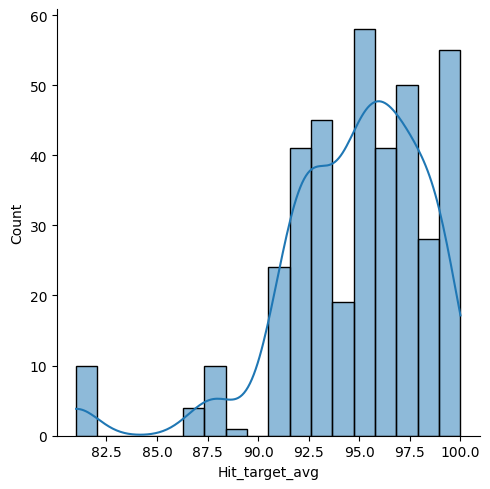

In [29]:
sns.displot(data=df["Hit_target_avg"], kde=True )

# Objetivo 2

Pregunta: Podem identificar perfils amb major risc de baix rendiment i fer ajustaments en l’organització per potenciar els resultats?

## Opción 1: ver si los clusters sociodemográficos presentan distinto rendimiento


Kruskal–Wallis test amb cluster sociodemografic: H=9.234, p-value=0.0263
Estadístiques descriptives de Hit_target per cluster:
                                                     mean   std  count
cluster_sociodemografic                                               
Adultos, casi sin hijos, transporte medio, muy ...  94.08  3.66     68
Adultos, pocos hijos, distancia media, bebedore...  94.80  2.80    143
Jovenes adultos, muchos hijos, gasto transporte...  95.19  4.41     69
Jovenes, pocos hijos, poco transporte, no beben...  94.61  4.02    106


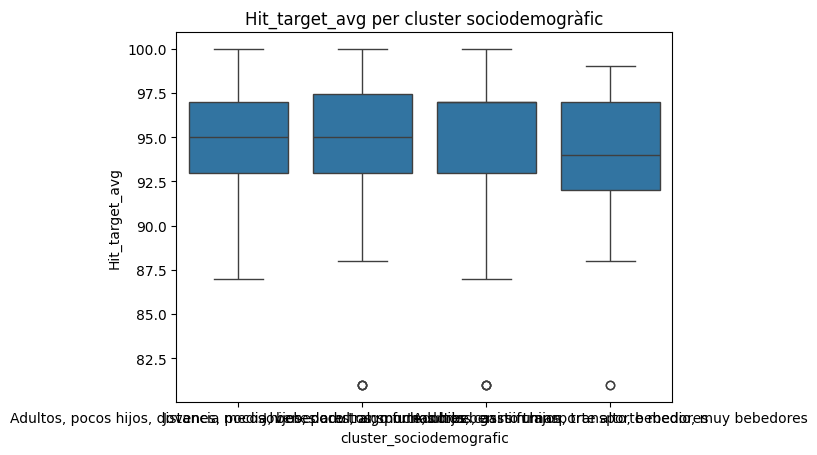

In [10]:
from scipy.stats import kruskal

groups = [df[df["cluster_sociodemografic"] == c]["Hit_target_avg"].dropna() for c in sorted(df["cluster_sociodemografic"].unique())]

stat, p = kruskal(*groups)
print(f"\nKruskal–Wallis test amb cluster sociodemografic: H={stat:.3f}, p-value={p:.4f}")

# Mitjana, desviació estàndard i nombre de casos per cluster
print("Estadístiques descriptives de Hit_target per cluster:")
print(df.groupby("cluster_sociodemografic")["Hit_target_avg"].agg(['mean', 'std', 'count']).round(2))

sns.boxplot(x="cluster_sociodemografic", y="Hit_target_avg", data=df)
plt.title("Hit_target_avg per cluster sociodemogràfic")
plt.show()

## Opción 2: mirar el efecto de las variables personales sobre el rendimiento

### Correlaciones

### Correlación entre rendimiento y variables personales numéricas

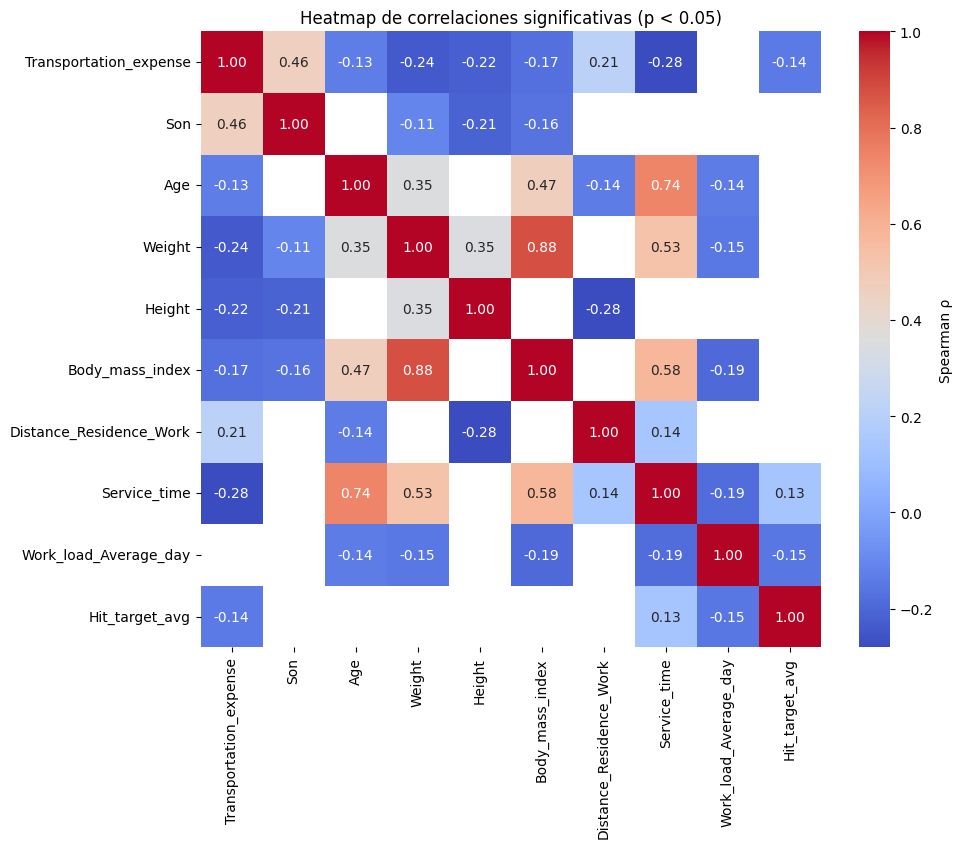

In [11]:
# Variables de interés
vars_interes = [
    "Transportation_expense", "Son","Age","Weight","Height","Body_mass_index","Distance_Residence_Work","Service_time","Work_load_Average_day","Hit_target_avg"
]

# Inicializar matrices de correlación y p-valores
n = len(vars_interes)
corr_matrix = pd.DataFrame(np.zeros((n, n)), index=vars_interes, columns=vars_interes)
pval_matrix = pd.DataFrame(np.zeros((n, n)), index=vars_interes, columns=vars_interes)

# Calcular rho y p-valor para cada par de variables
for i in range(n):
    for j in range(n):
        rho, pval = spearmanr(df[vars_interes[i]], df[vars_interes[j]], nan_policy="omit")
        corr_matrix.iloc[i, j] = rho
        pval_matrix.iloc[i, j] = pval

# Enmascarar las correlaciones no significativas
mask = pval_matrix >= 0.05
corr_sig = corr_matrix.mask(mask)

# Graficar heatmap solo con correlaciones significativas
plt.figure(figsize=(10, 8))
sns.heatmap(corr_sig, annot=True, fmt=".2f", cmap="coolwarm", mask=mask, cbar_kws={'label': 'Spearman ρ'})
plt.title("Heatmap de correlaciones significativas (p < 0.05)")
plt.show()



#### Relación entre rendimiento y variables personales categóricas

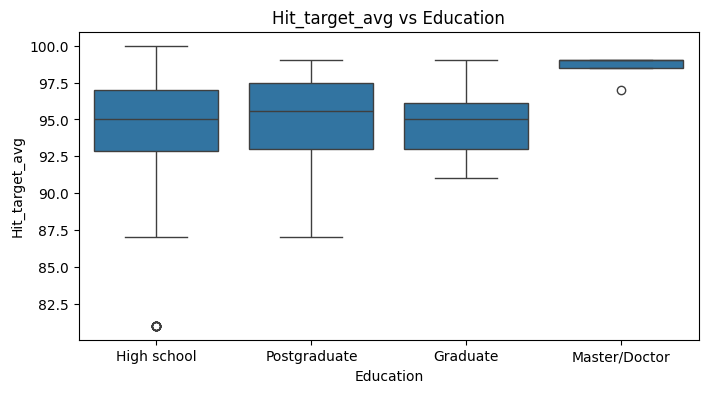

Education - p-value Kruskal-Wallis: 0.0790


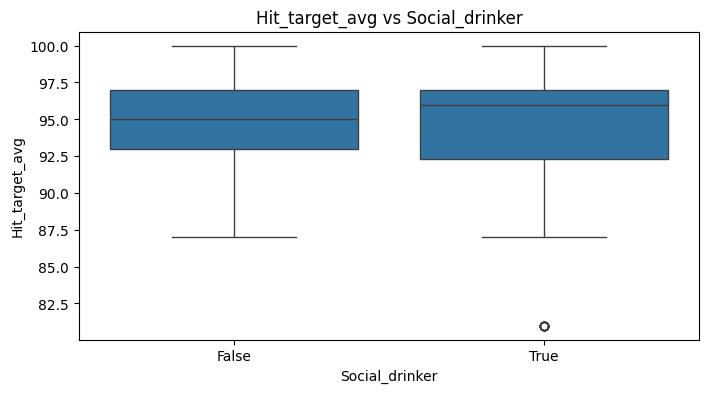

Social_drinker - p-value Mann-Whitney U: 0.2736


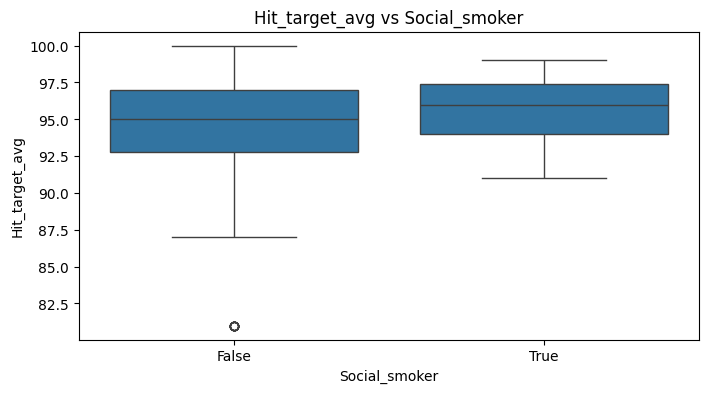

Social_smoker - p-value Mann-Whitney U: 0.1701


In [12]:
from scipy import stats

# Lista de targets y variables categóricas
targets = ["Hit_target_avg"] 
cat_vars = ['Education', 'Social_drinker', 'Social_smoker']

# Función para graficar y aplicar test estadístico
def analyze_categorical(target, cat_vars, df):
    for col in cat_vars:
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=col, y=target, data=df)
        plt.title(f"{target} vs {col}")
        plt.show()

        # Separar en grupos según la categoría
        groups = [group[target].values for name, group in df.groupby(col)]

        # Aplicar test estadístico según tipo de variable
        if col == "Education" and len(groups) > 1:
            kruskal = stats.kruskal(*groups)
            print(f"{col} - p-value Kruskal-Wallis: {kruskal.pvalue:.4f}")
        elif len(groups) == 2:
            mannwhitney = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
            print(f"{col} - p-value Mann-Whitney U: {mannwhitney.pvalue:.4f}")
        else:
            print(f"{col} - No se ha aplicado test estadístico")

# Ejecutar para todos los targets
for target in targets:
    analyze_categorical(target, cat_vars, df)



## Modelo predictivo

In [13]:
# Passar les categòriques/binomials a object
cat_vars = ['Education', 'Social_drinker', 'Social_smoker']
for col in cat_vars:
    df[col] = df[col].astype(str).str.strip()

In [14]:
import statsmodels.formula.api as smf

# 1. Escalar la resposta a [0,1]
df["hit_target_avg_scaled"] = df["Hit_target_avg"] / 100

# 2. Ajustar els valors per evitar 0 i 1 exactes (sinó el logit peta)
eps = 1e-6
df["hit_target_avg_scaled"] = df["hit_target_avg_scaled"].clip(eps, 1 - eps)

# 3. Transformació logit
df["hit_target_avg_logit"] = np.log(df["hit_target_avg_scaled"] / (1 - df["hit_target_avg_scaled"]))

# 4. Definir la fórmula del model amb predictors
formula = 'hit_target_avg_logit ~  Transportation_expense + Distance_Residence_Work + Service_time + Age + Work_load_Average_day + Son + Weight + Height + Body_mass_index + Education + Social_drinker + Social_smoker'

# 5. Ajustar regressió lineal (OLS)
model = smf.glm(formula, data=df).fit()

# 6. Resultats
print(model.summary())

# 7. Si vols prediccions en l'escala original (0-100):
df["pred_logit"] = model.predict(df)
df["pred_scaled"] = 1 / (1 + np.exp(-df["pred_logit"]))  # inverse logit
df["pred_original"] = df["pred_scaled"] * 100

                  Generalized Linear Model Regression Results                   
Dep. Variable:     hit_target_avg_logit   No. Observations:                  386
Model:                              GLM   Df Residuals:                      371
Model Family:                  Gaussian   Df Model:                           14
Link Function:                 Identity   Scale:                          2.0341
Method:                            IRLS   Log-Likelihood:                -677.10
Date:                  Wed, 08 Oct 2025   Deviance:                       754.66
Time:                          12:28:13   Pearson chi2:                     755.
No. Iterations:                       3   Pseudo R-squ. (CS):            0.05312
Covariance Type:              nonrobust                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
